#### ============================================
###  1. Import Libraries
#### ============================================

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### ============================================
###  2. Read a Data
#### ============================================

In [63]:
Data = pd.read_csv("/Users/mac/Desktop/Zain Projects/Task 1 Salary Dataset/data/Salaries.csv")

/var/folders/qp/phjgxp894ns8_sk2pqy1hqjh0000gn/T/ipykernel_6523/1942613967.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  Data = pd.read_csv("/Users/mac/Desktop/Zain Projects/Task 1 Salary Dataset/data/Salaries.csv")


#### ============================================
###  3. Data Cleaning
#### ============================================

###  3.1 Quick Look about Data

In [64]:
Data.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [65]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148648 entries, 0 to 148647
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148648 non-null  int64  
 1   EmployeeName      148648 non-null  object 
 2   JobTitle          148648 non-null  object 
 3   BasePay           148043 non-null  float64
 4   OvertimePay       148648 non-null  float64
 5   OtherPay          148648 non-null  float64
 6   Benefits          112490 non-null  float64
 7   TotalPay          148648 non-null  float64
 8   TotalPayBenefits  148648 non-null  float64
 9   Year              148648 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148648 non-null  object 
 12  Status            38119 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 14.7+ MB


In [66]:
Data.duplicated().sum()

0

###  3.2 Checking a null values in Data and cleaned

In [67]:
Data.isnull().sum()

Id                       0
EmployeeName             0
JobTitle                 0
BasePay                605
OvertimePay              0
OtherPay                 0
Benefits             36158
TotalPay                 0
TotalPayBenefits         0
Year                     0
Notes               148648
Agency                   0
Status              110529
dtype: int64

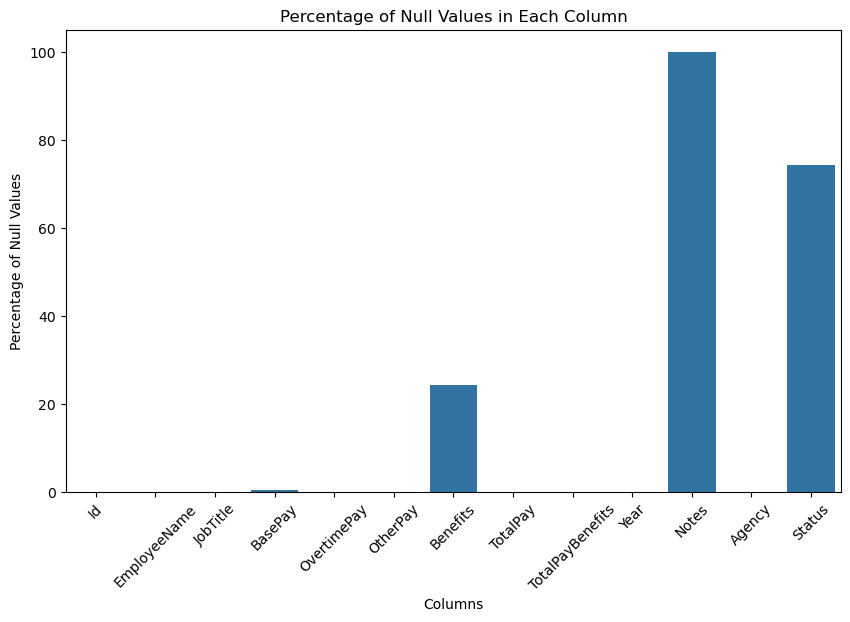

In [68]:
# This Chart Showing the percentage of null values in each column
plt.figure(figsize=(10, 6))
sns.barplot(x=Data.columns, y=Data.isnull().mean() * 100)
plt.title("Percentage of Null Values in Each Column")
plt.ylabel("Percentage of Null Values")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()

In [69]:
# Drop a Notes column because it has a high percentage of null values
Data.drop("Notes", axis=1, inplace=True)

In [70]:
# And Drop a Status column because it has a high percentage of null values
Data.drop("Status", axis=1, inplace=True)

###  3.3 Drop a Id Column

In [71]:
# Drop a Id column because it is not useful for our analysis
Data.drop("Id", axis=1, inplace=True)

###  3.4 Imputation a BasePay Column

In [72]:
# Cleaning the BasePay using Mean
Data["BasePay"].fillna(Data["BasePay"].mean(), inplace=True)

/var/folders/qp/phjgxp894ns8_sk2pqy1hqjh0000gn/T/ipykernel_6523/1192756696.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data["BasePay"].fillna(Data["BasePay"].mean(), inplace=True)


In [73]:
Data.isnull().sum()

EmployeeName            0
JobTitle                0
BasePay                 0
OvertimePay             0
OtherPay                0
Benefits            36158
TotalPay                0
TotalPayBenefits        0
Year                    0
Agency                  0
dtype: int64

###  3.5 Imputation a Benefits Column

In [74]:
Data["Benefits"].value_counts().head()

Benefits
0.00        1734
7959.18      348
4659.36      107
25699.20      83
37055.22      82
Name: count, dtype: int64

In [75]:
# Cleaning the Benefits using Median
Data["Benefits"].fillna(Data["Benefits"].median(), inplace=True)

/var/folders/qp/phjgxp894ns8_sk2pqy1hqjh0000gn/T/ipykernel_6523/2605109142.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data["Benefits"].fillna(Data["Benefits"].median(), inplace=True)


In [76]:
Data.isnull().sum()

EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
Agency              0
dtype: int64

###  3.6 Check Outliers

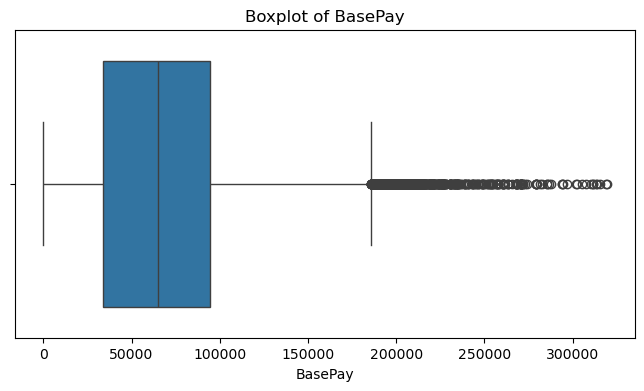

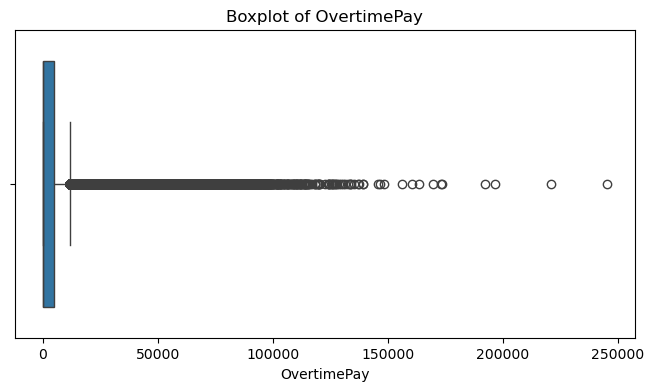

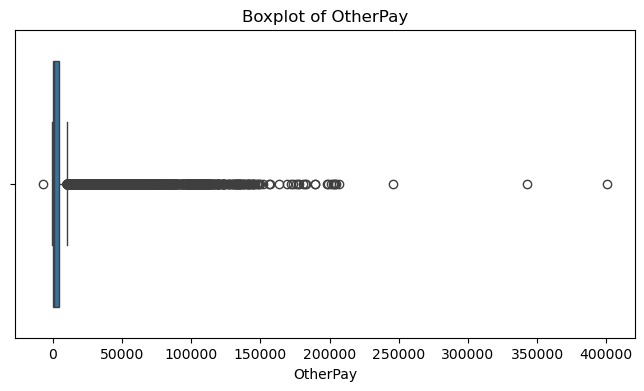

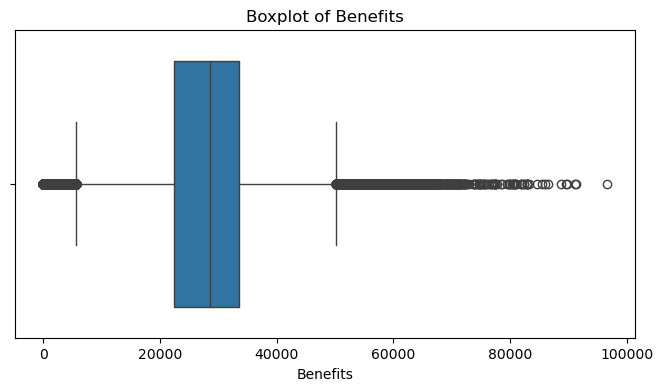

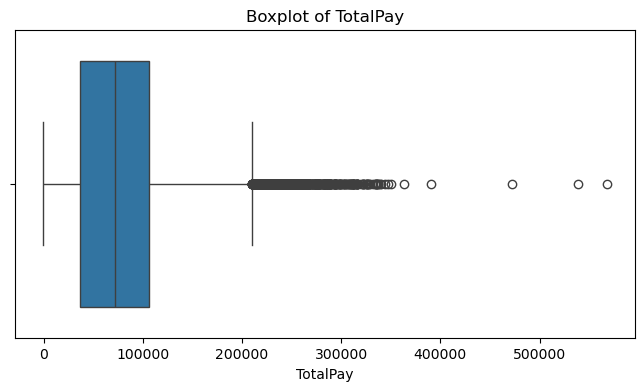

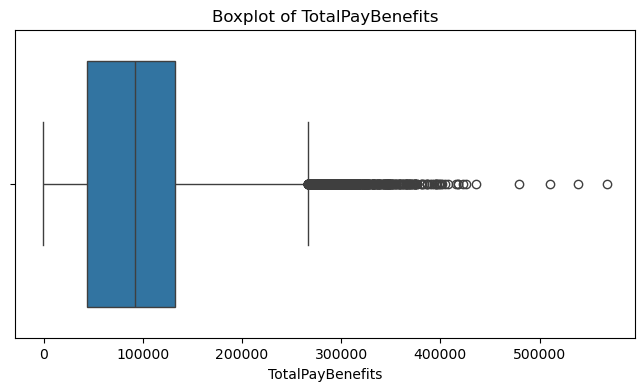

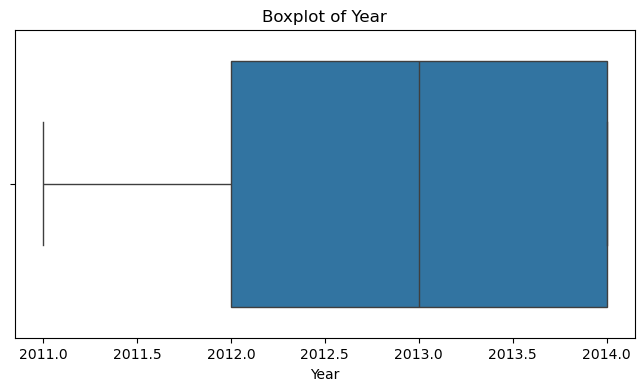

In [77]:
# Checking the Outliers in the Numeric Columns
numeric_cols = Data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=Data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [78]:
for col in numeric_cols:

    Q1 = Data[col].quantile(0.25)
    Q3 = Data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = Data[
        (Data[col] < lower_bound) |
        (Data[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

BasePay: 1080 outliers
OvertimePay: 20186 outliers
OtherPay: 15179 outliers
Benefits: 26755 outliers
TotalPay: 1286 outliers
TotalPayBenefits: 933 outliers
Year: 0 outliers


In [79]:
Data[Data['OvertimePay'] < 0]

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency
90712,Claudia M Sanchez,Senior Eligibility Worker,75033.03,-0.01,1540.0,28864.64,76573.02,105437.66,2013,San Francisco


In [80]:
Data['OvertimePay'] = Data['OvertimePay'].apply(lambda x: 0 if x < 0 else x)

In [81]:
Data[Data['OvertimePay'] < 0]['OvertimePay'].value_counts()

Series([], Name: count, dtype: int64)

In [82]:
cols = [
    'BasePay',
    'OvertimePay',
    'OtherPay',
    'Benefits',
    'TotalPay',
    'TotalPayBenefits'
]

for col in cols:
    Data[col] = np.log1p(Data[col])

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


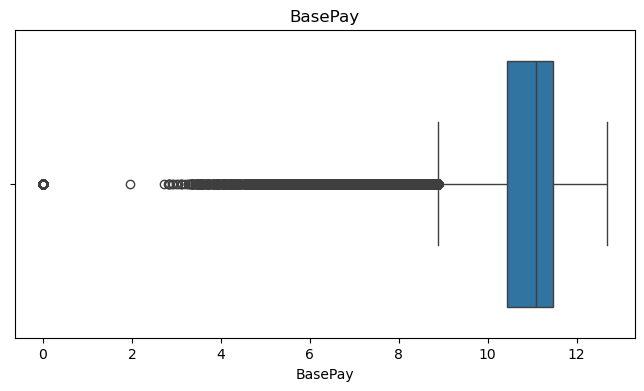

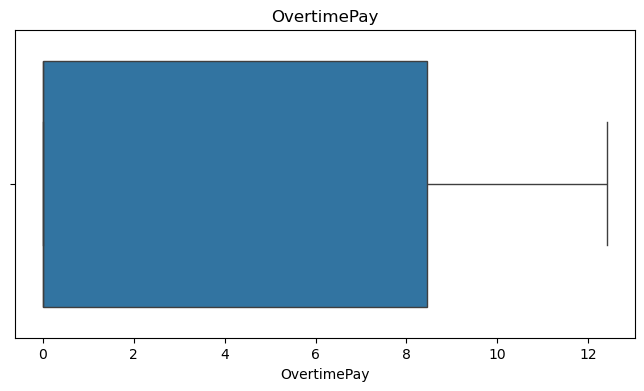

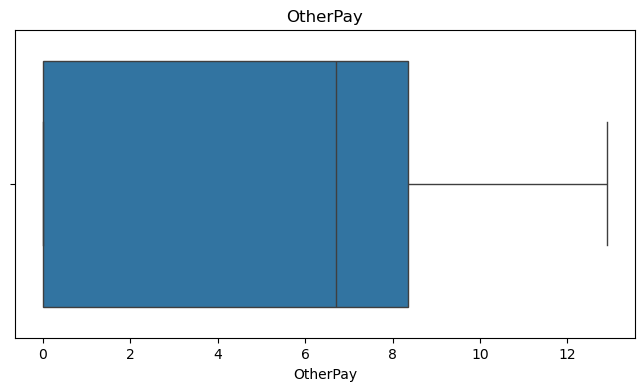

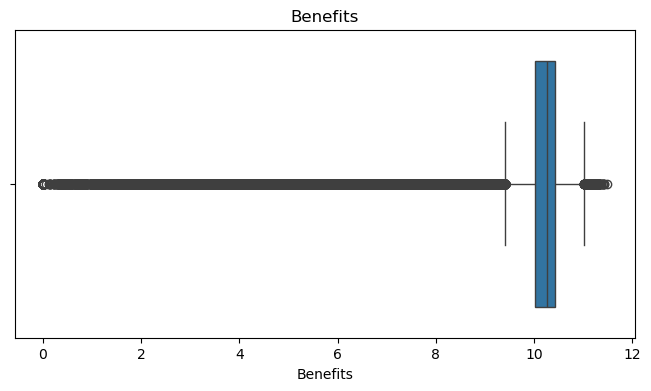

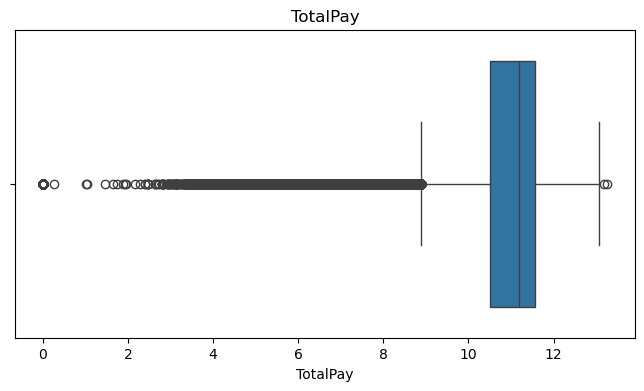

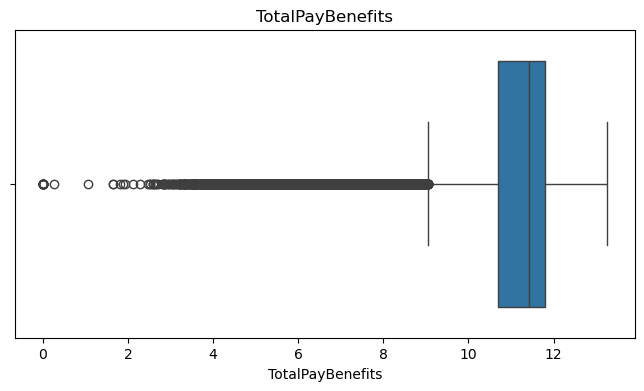

In [83]:
for col in cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=Data[col])
    plt.title(col)
    plt.show()

In [84]:
for col in numeric_cols:

    Q1 = Data[col].quantile(0.25)
    Q3 = Data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = Data[
        (Data[col] < lower_bound) |
        (Data[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

BasePay: 15186 outliers
OvertimePay: 0 outliers
OtherPay: 0 outliers
Benefits: 29048 outliers
TotalPay: 14758 outliers
TotalPayBenefits: 15558 outliers
Year: 0 outliers


In [85]:
(Data[cols] < 0).sum()

BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
dtype: int64

In [91]:
Data.isnull().sum()

EmployeeName         0
JobTitle             0
BasePay             11
OvertimePay          0
OtherPay             5
Benefits             4
TotalPay             1
TotalPayBenefits     4
Year                 0
Agency               0
dtype: int64

In [92]:
Data.dropna(inplace=True)

In [93]:
Data.isnull().sum()

EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
Agency              0
dtype: int64

In [94]:
Data.to_csv("/Users/mac/Desktop/Zain Projects/Task 1 Salary Dataset/data/Cleaned_Salaries.csv", index=False)